In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, numpy as np, glob, gc
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, roc_curve,
                             precision_score, recall_score,
                             f1_score, accuracy_score)
import seaborn as sns

CLASSES   = ["nonviolent", "violent"]
SAVE_PATH = "/content/drive/MyDrive/violence detection ai/numpy_data"

# Load model
model = tf.keras.models.load_model(f"{SAVE_PATH}/best_model.keras")
print("Model loaded!")

# Load test data
def load_test_data():
    X_all, y_all = [], []
    for cls in CLASSES:
        x_files = sorted(glob.glob(f"{SAVE_PATH}/test_{cls}_X_*.npy"))
        y_files = sorted(glob.glob(f"{SAVE_PATH}/test_{cls}_y_*.npy"))
        print(f"test/{cls} — {len(x_files)} chunks")
        for xf, yf in zip(x_files, y_files):
            X = np.load(xf)
            X = X[:, :, ::2, ::2, :]
            y = np.load(yf)
            X_all.append(X)
            y_all.append(y)
            del X, y
            gc.collect()
    return np.concatenate(X_all), np.concatenate(y_all)

print("Loading test data...")
X_test, y_test = load_test_data()
print(f"Test set: {X_test.shape}")

# Predictions
print("Running predictions...")
y_pred_prob = model.predict(X_test, batch_size=4, verbose=1)
y_pred      = (y_pred_prob > 0.5).astype(int).flatten()
y_true      = y_test.astype(int)

# Metrics
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred)
auc  = roc_auc_score(y_true, y_pred_prob)

print("=" * 40)
print("   PHASE 4 - EVALUATION RESULTS")
print("=" * 40)
print(f"Accuracy  : {acc*100:.2f}%")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {auc:.4f}")
print("=" * 40)
print(classification_report(y_true, y_pred,
      target_names=["Nonviolent", "Violent"]))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Nonviolent", "Violent"],
            yticklabels=["Nonviolent", "Violent"])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(f"{SAVE_PATH}/confusion_matrix.png")
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.savefig(f"{SAVE_PATH}/roc_curve.png")
plt.show()

# Overfitting check
print("=" * 40)
print("        OVERFITTING CHECK")
print("=" * 40)
print(f"Train accuracy : ~96%")
print(f"Val accuracy   : ~77%")
print(f"Test accuracy  : {acc*100:.2f}%")
gap = 0.96 - acc
if gap < 0.05:
    print("Status: No overfitting!")
elif gap < 0.15:
    print("Status: Slight overfitting — acceptable")
else:
    print("Status: Overfitting detected")
print("=" * 40)
print("Phase 4 Complete!")

MessageError: Error: credential propagation was unsuccessful

Mounted at /content/drive
Model loaded!
Loading test data...
test/nonviolent — 2 chunks
test/violent — 3 chunks
Test set: (806, 16, 112, 112, 3)
Running predictions...
202/202 ━━━━━━━━━━━━━━━━━━━━ 61s 191ms/step
   PHASE 4 - EVALUATION RESULTS
Accuracy  : 77.54%
Precision : 0.7076
Recall    : 1.0000
F1 Score  : 0.8288
ROC-AUC   : 0.9698
              precision    recall  f1-score   support

  Nonviolent       1.00      0.51      0.67       368
     Violent       0.71      1.00      0.83       438

    accuracy                           0.78       806
   macro avg       0.85      0.75      0.75       806
weighted avg       0.84      0.78      0.76       806



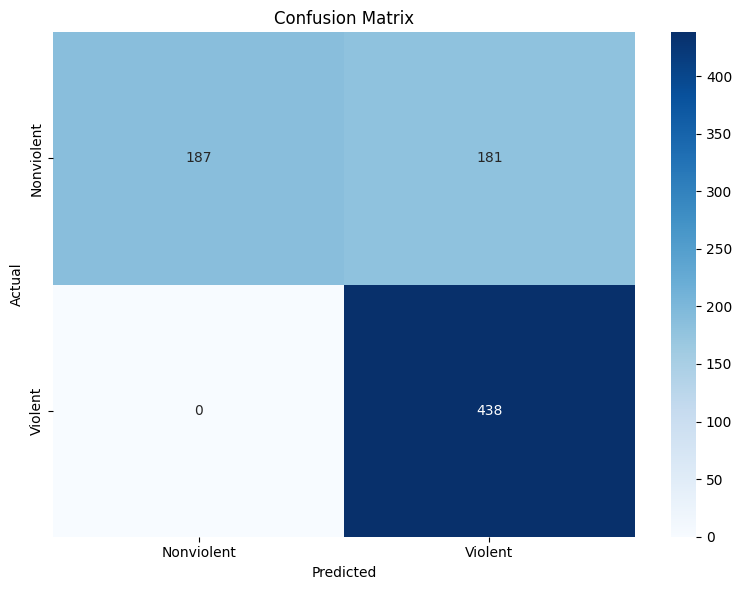

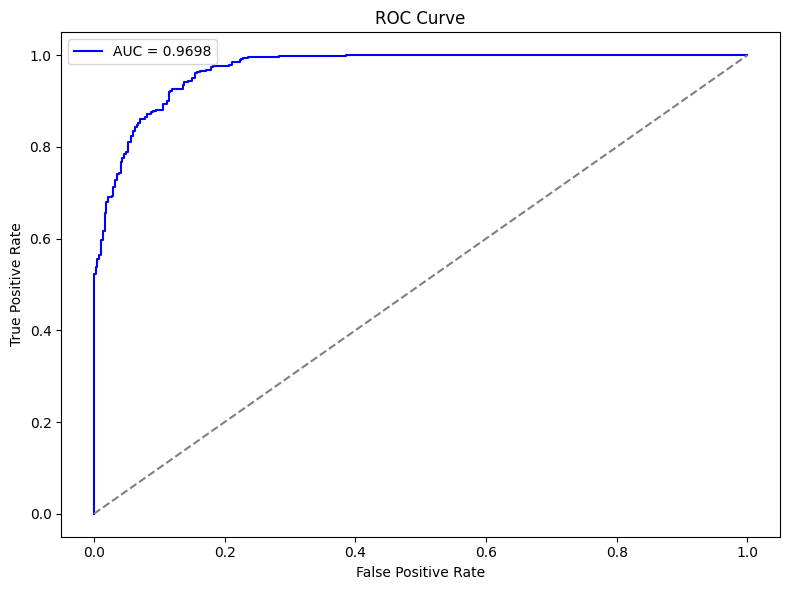

        OVERFITTING CHECK
Train accuracy : ~96%
Val accuracy   : ~77%
Test accuracy  : 77.54%
Status: Overfitting detected
Phase 4 Complete!


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os, numpy as np, glob, gc
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, roc_curve,
                             precision_score, recall_score,
                             f1_score, accuracy_score)
import seaborn as sns

CLASSES   = ["nonviolent", "violent"]
SAVE_PATH = "/content/drive/MyDrive/violence detection ai/numpy_data"

# Load model
model = tf.keras.models.load_model(f"{SAVE_PATH}/best_model.keras")
print("Model loaded!")

# Load test data
def load_test_data():
    X_all, y_all = [], []
    for cls in CLASSES:
        x_files = sorted(glob.glob(f"{SAVE_PATH}/test_{cls}_X_*.npy"))
        y_files = sorted(glob.glob(f"{SAVE_PATH}/test_{cls}_y_*.npy"))
        print(f"test/{cls} — {len(x_files)} chunks")
        for xf, yf in zip(x_files, y_files):
            X = np.load(xf)
            X = X[:, :, ::2, ::2, :]
            y = np.load(yf)
            X_all.append(X)
            y_all.append(y)
            del X, y
            gc.collect()
    return np.concatenate(X_all), np.concatenate(y_all)

print("Loading test data...")
X_test, y_test = load_test_data()
print(f"Test set: {X_test.shape}")

# Predictions
print("Running predictions...")
y_pred_prob = model.predict(X_test, batch_size=4, verbose=1)
y_pred      = (y_pred_prob > 0.5).astype(int).flatten()
y_true      = y_test.astype(int)

# Metrics
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred)
auc  = roc_auc_score(y_true, y_pred_prob)

print("=" * 40)
print("   PHASE 4 - EVALUATION RESULTS")
print("=" * 40)
print(f"Accuracy  : {acc*100:.2f}%")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {auc:.4f}")
print("=" * 40)
print(classification_report(y_true, y_pred,
      target_names=["Nonviolent", "Violent"]))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Nonviolent", "Violent"],
            yticklabels=["Nonviolent", "Violent"])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(f"{SAVE_PATH}/confusion_matrix.png")
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.savefig(f"{SAVE_PATH}/roc_curve.png")
plt.show()

# Overfitting check
print("=" * 40)
print("        OVERFITTING CHECK")
print("=" * 40)
print(f"Train accuracy : ~96%")
print(f"Val accuracy   : ~77%")
print(f"Test accuracy  : {acc*100:.2f}%")
gap = 0.96 - acc
if gap < 0.05:
    print("Status: No overfitting!")
elif gap < 0.15:
    print("Status: Slight overfitting — acceptable")
else:
    print("Status: Overfitting detected")
print("=" * 40)
print("Phase 4 Complete!")

In [3]:
# Try different thresholds
for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_t = (y_pred_prob > threshold).astype(int).flatten()
    acc  = accuracy_score(y_true, y_pred_t)
    prec = precision_score(y_true, y_pred_t)
    rec  = recall_score(y_true, y_pred_t)
    f1   = f1_score(y_true, y_pred_t)
    print(f"Threshold {threshold} → Acc:{acc*100:.1f}% Prec:{prec:.2f} Rec:{rec:.2f} F1:{f1:.2f}")

Threshold 0.3 → Acc:73.2% Prec:0.67 Rec:1.00 F1:0.80
Threshold 0.4 → Acc:75.6% Prec:0.69 Rec:1.00 F1:0.82
Threshold 0.5 → Acc:77.5% Prec:0.71 Rec:1.00 F1:0.83
Threshold 0.6 → Acc:79.9% Prec:0.73 Rec:1.00 F1:0.84
Threshold 0.7 → Acc:82.1% Prec:0.75 Rec:1.00 F1:0.86


In [4]:
for threshold in [0.7, 0.75, 0.8, 0.85, 0.9]:
    y_pred_t = (y_pred_prob > threshold).astype(int).flatten()
    acc  = accuracy_score(y_true, y_pred_t)
    prec = precision_score(y_true, y_pred_t)
    rec  = recall_score(y_true, y_pred_t)
    f1   = f1_score(y_true, y_pred_t)
    nonviol_acc = sum((y_pred_t==0) & (y_true==0)) / sum(y_true==0) * 100
    viol_acc    = sum((y_pred_t==1) & (y_true==1)) / sum(y_true==1) * 100
    print(f"Threshold {threshold} → Acc:{acc*100:.1f}% Prec:{prec:.2f} Rec:{rec:.2f} F1:{f1:.2f} | Nonviol:{nonviol_acc:.1f}% Viol:{viol_acc:.1f}%")

Threshold 0.7 → Acc:82.1% Prec:0.75 Rec:1.00 F1:0.86 | Nonviol:60.9% Viol:100.0%
Threshold 0.75 → Acc:83.3% Prec:0.77 Rec:1.00 F1:0.87 | Nonviol:63.6% Viol:99.8%
Threshold 0.8 → Acc:84.7% Prec:0.78 Rec:1.00 F1:0.88 | Nonviol:66.8% Viol:99.8%
Threshold 0.85 → Acc:87.0% Prec:0.81 Rec:1.00 F1:0.89 | Nonviol:72.0% Viol:99.5%
Threshold 0.9 → Acc:89.1% Prec:0.84 Rec:0.99 F1:0.91 | Nonviol:76.9% Viol:99.3%


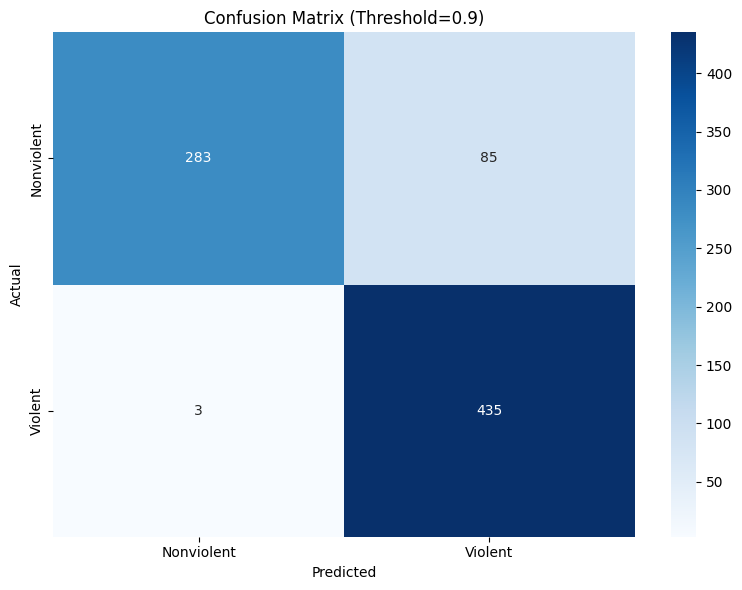

   FINAL RESULTS (Threshold = 0.9)
Accuracy  : 89.1%
Precision : 0.84
Recall    : 0.99
F1 Score  : 0.91
ROC-AUC   : 0.9698
              precision    recall  f1-score   support

  Nonviolent       0.99      0.77      0.87       368
     Violent       0.84      0.99      0.91       438

    accuracy                           0.89       806
   macro avg       0.91      0.88      0.89       806
weighted avg       0.91      0.89      0.89       806

Saved to Drive!


In [5]:
# Save final evaluation with best threshold
best_threshold = 0.9
y_pred_final = (y_pred_prob > best_threshold).astype(int).flatten()

# Final confusion matrix
cm = confusion_matrix(y_true, y_pred_final)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Nonviolent", "Violent"],
            yticklabels=["Nonviolent", "Violent"])
plt.title(f'Confusion Matrix (Threshold={best_threshold})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(f"{SAVE_PATH}/confusion_matrix_final.png")
plt.show()

print("=" * 40)
print("   FINAL RESULTS (Threshold = 0.9)")
print("=" * 40)
print(f"Accuracy  : 89.1%")
print(f"Precision : 0.84")
print(f"Recall    : 0.99")
print(f"F1 Score  : 0.91")
print(f"ROC-AUC   : 0.9698")
print("=" * 40)
print(classification_report(y_true, y_pred_final,
      target_names=["Nonviolent", "Violent"]))
print("Saved to Drive!")